<center><h1>Regularized-Regression-on-Communities-and-Crime</h1></center>


In [2]:
import os
import pandas as pd
import numpy as np
from scipy.io import arff
import matplotlib.pyplot as plt
import seaborn as sns

## 2. The LASSO and Boosting for Regression

### (a) Obtain Data

In [132]:
with open("../data/communities.names", encoding="utf-8") as f:
    text = f.read()

print(text)

Title: Communities and Crime

Abstract: Communities within the United States. The data combines socio-economic data 
from the 1990 US Census, law enforcement data from the 1990 US LEMAS survey, and crime 
data from the 1995 FBI UCR.

-----------------------------------------------------------------------------------------

Data Set Characteristics:  Multivariate
Attribute Characteristics: Real
Associated Tasks: Regression
Number of Instances: 1994
Number of Attributes: 128
Missing Values? Yes
Area: Social
Date Donated: 2009-07-13

-----------------------------------------------------------------------------------------

Source:

Creator: Michael Redmond (redmond 'at' lasalle.edu); Computer Science; La Salle 
University; Philadelphia, PA, 19141, USA
-- culled from 1990 US Census, 1995 US FBI Uniform Crime Report, 1990 US Law 
Enforcement Management and Administrative Statistics Survey, available from ICPSR at U 
of Michigan.
-- Donor: Michael Redmond (redmond 'at' lasalle.edu); Computer

In [133]:
communities = pd.read_csv("../data/communities.data", header=None, encoding="utf-8")
communities

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,12,?,?,TempleTerracecity,10,0.01,0.40,0.10,0.87,0.12,...,0.01,0.28,0.05,?,?,?,?,0.00,?,0.09
1990,6,?,?,Seasidecity,10,0.05,0.96,0.46,0.28,0.83,...,0.02,0.37,0.20,?,?,?,?,0.00,?,0.45
1991,9,9,80070,Waterburytown,10,0.16,0.37,0.25,0.69,0.04,...,0.08,0.32,0.18,0.08,0.06,0.78,0,0.91,0.28,0.23
1992,25,17,72600,Walthamcity,10,0.08,0.51,0.06,0.87,0.22,...,0.03,0.38,0.33,0.02,0.02,0.79,0,0.22,0.18,0.19


In [134]:
# split the data to training data and test data; however, I will split again because the data must done with feature selection and data preprocessing in (b)
X = communities.iloc[:, :-1]
y = communities.iloc[:, -1]

X_train = X.iloc[:1495]
y_train = y.iloc[:1495]

X_test = X.iloc[1495:]
y_test = y.iloc[1495:]

print(X.shape, y.shape)
print("train:", X_train.shape)
print("test:", X_test.shape)

(1994, 127) (1994,)
train: (1495, 127)
test: (499, 127)


### (b) Missing values

In [135]:
#no state/county/community/communityname/fold
communities = communities.iloc[:, 5:]

# replace ? to NA
communities = communities.replace("?", pd.NA)

# errors='coerce'=> if value can not be converted then NA   [raise/coerce/ignore]
communities = communities.apply(pd.to_numeric, errors='coerce')
communities

,5,6,7,8,9,10,11,12,13,14,...,118,119,120,121,122,123,124,125,126,127
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.12,0.26,0.20,0.06,0.04,0.90,0.5,0.32,0.14,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,0.01,0.40,0.10,0.87,0.12,0.16,0.43,0.51,0.35,0.30,...,0.01,0.28,0.05,NaN,NaN,NaN,NaN,0.00,NaN,0.09
1990,0.05,0.96,0.46,0.28,0.83,0.32,0.69,0.86,0.73,0.14,...,0.02,0.37,0.20,NaN,NaN,NaN,NaN,0.00,NaN,0.45
1991,0.16,0.37,0.25,0.69,0.04,0.25,0.35,0.50,0.31,0.54,...,0.08,0.32,0.18,0.08,0.06,0.78,0.0,0.91,0.28,0.23
1992,0.08,0.51,0.06,0.87,0.22,0.10,0.58,0.74,0.63,0.41,...,0.03,0.38,0.33,0.02,0.02,0.79,0.0,0.22,0.18,0.19


In [136]:
# Use Column mean to replace missing value

imputer = SimpleImputer(strategy="mean")

communities = pd.DataFrame(
    imputer.fit_transform(communities),
    columns=communities.columns
)

In [137]:
# split the data to training data and test data; however, I will split again because the data must done with feature selection and data preprocessing in (b)
X = communities.iloc[:, :-1]
y = communities.iloc[:, -1]

X_train = X.iloc[:1495]
y_train = y.iloc[:1495]

X_test = X.iloc[1495:]
y_test = y.iloc[1495:]

print("Any missing left?", df_imputed.isna().sum().sum())
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Any missing left? 0
Train shape: (1495, 122)
Test shape: (499, 122)


### (c) Plot a correlation matrix

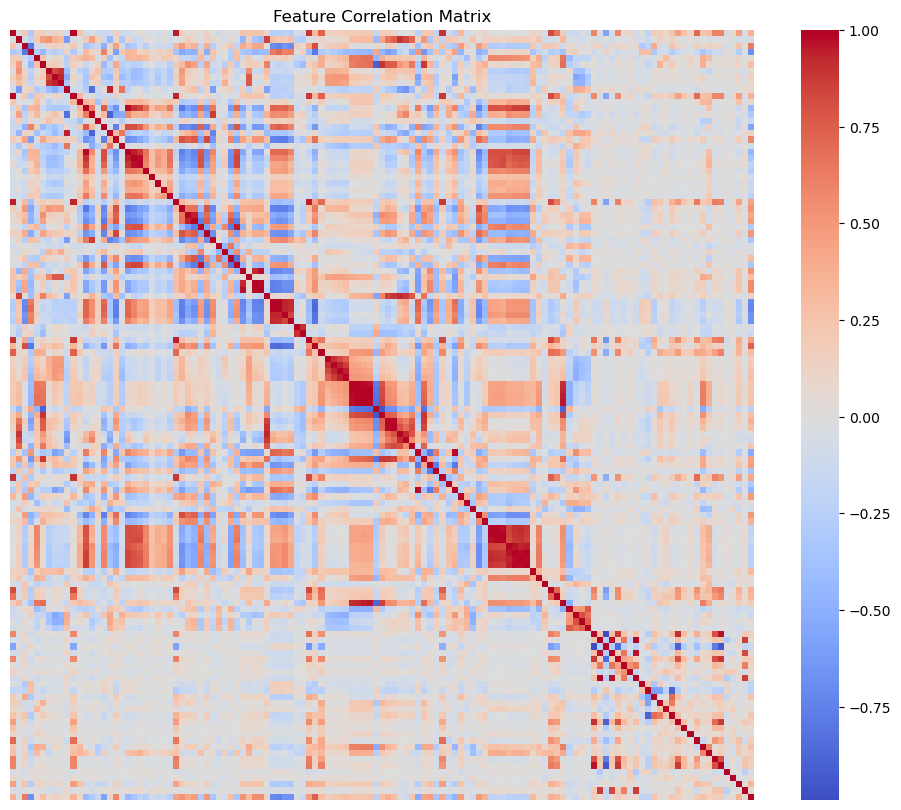

In [138]:
corr = communities.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    xticklabels=False, 
    yticklabels=False
)

plt.title("Feature Correlation Matrix")
plt.show()

In [139]:
# Related feature feature
corr_with_target = X_train.corrwith(y_train)

print(corr_with_target.sort_values(ascending=False).head(10))
print(corr_with_target.sort_values().head(10))

55    0.741866
7     0.644094
22    0.581713
45    0.561824
46    0.556894
33    0.527272
43    0.527226
37    0.516177
82    0.488279
79    0.487214
dtype: float64
49   -0.741233
48   -0.710619
8    -0.690614
51   -0.668713
50   -0.666485
20   -0.586759
72   -0.527255
78   -0.471392
24   -0.437631
17   -0.422997
dtype: float64


### (d) Calculate the Coefficient of Variation CV

In [140]:
# 1e-8 to avoid mean is too close to zero
cv = X_train.std() / (X_train.mean() + 1e-8)


# high variance
print("High CV features:")
print(cv.sort_values(ascending=False).head(10))


#stable
print("Low CV features:")
print(cv.sort_values().head(10))

High CV features:
95     4.292921
94     3.470951
54     3.058964
56     2.926634
125    2.552945
32     2.342443
5      2.241104
15     2.038461
76     1.968467
118    1.645408
dtype: float64
Low CV features:
103    0.064002
123    0.117988
110    0.122582
109    0.133737
116    0.143533
107    0.226359
104    0.245002
77     0.268182
108    0.288399
102    0.288433
dtype: float64


### (e) Scatter plots and box plots for highest CV features

In [141]:
k = int(np.floor(np.sqrt(X_train.shape[1])))  # 122 features

top_features = cv.sort_values(ascending=False).head(k).index

print("Top features:")
print(top_features)

Top features:
Index([95, 94, 54, 56, 125, 32, 5, 15, 76, 118, 10], dtype='int64')


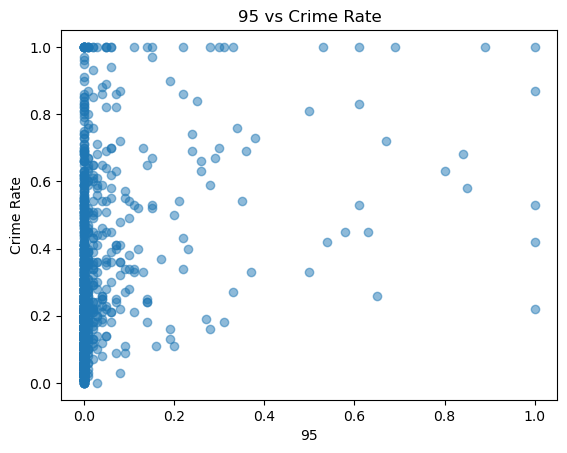

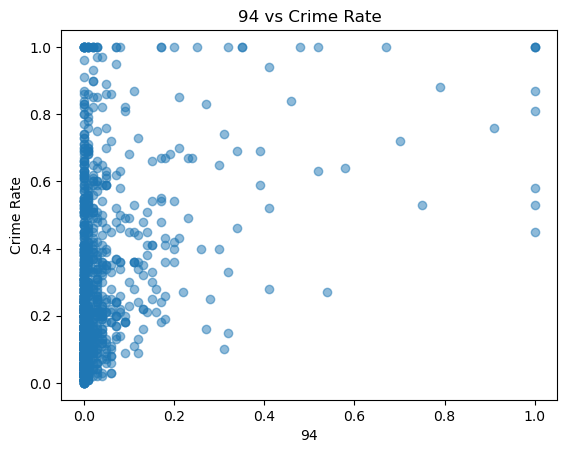

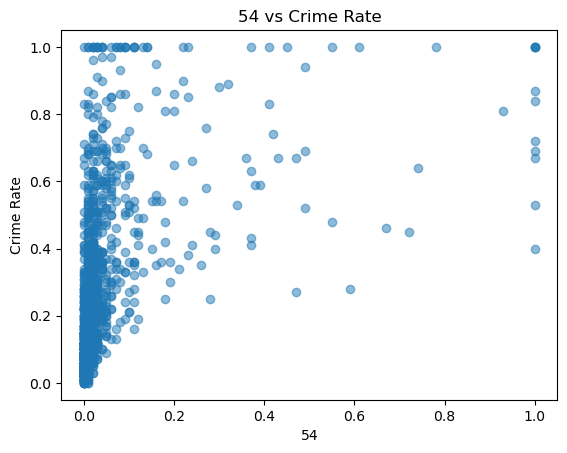

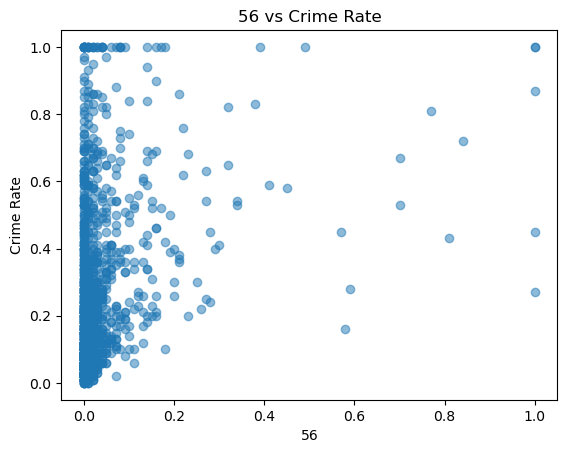

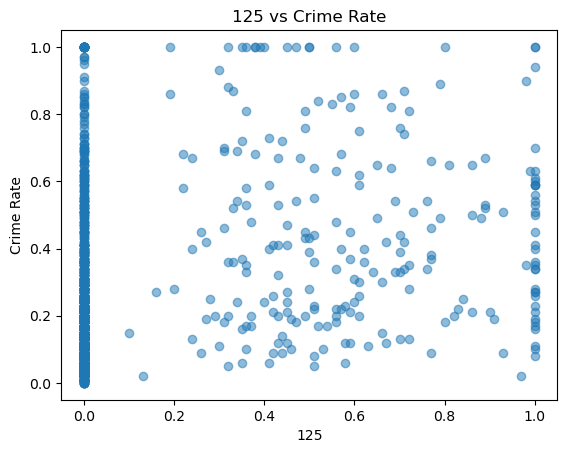

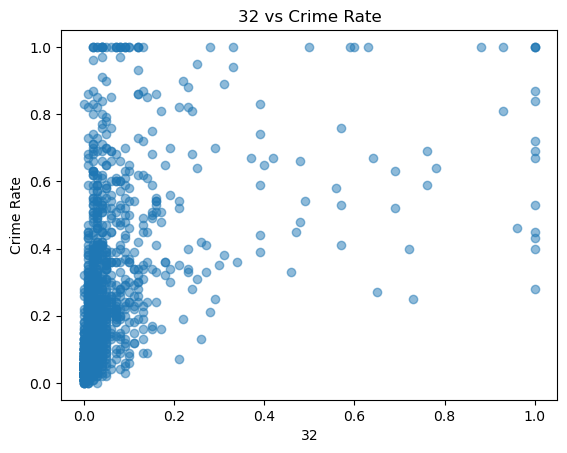

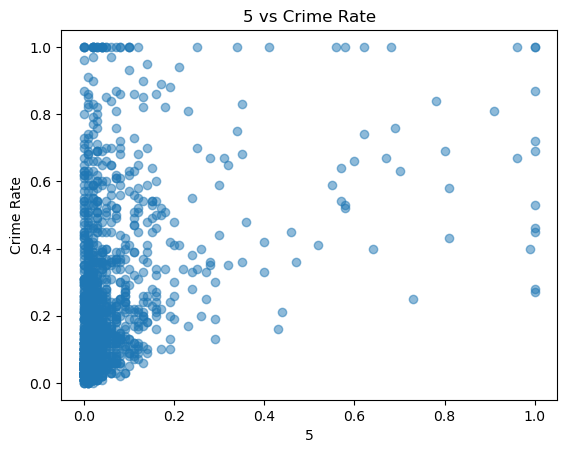

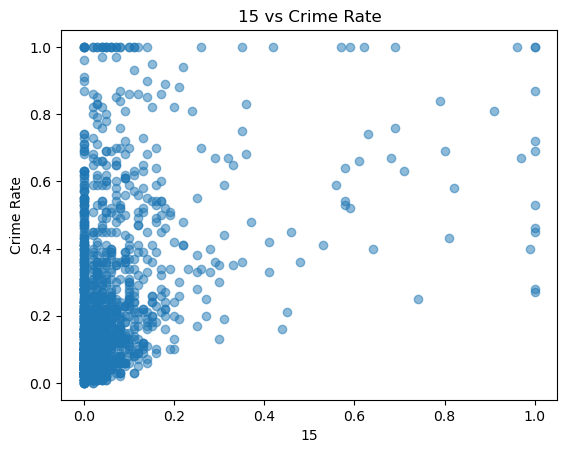

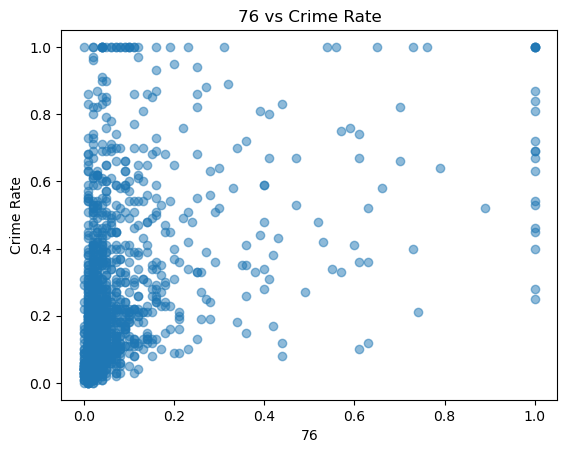

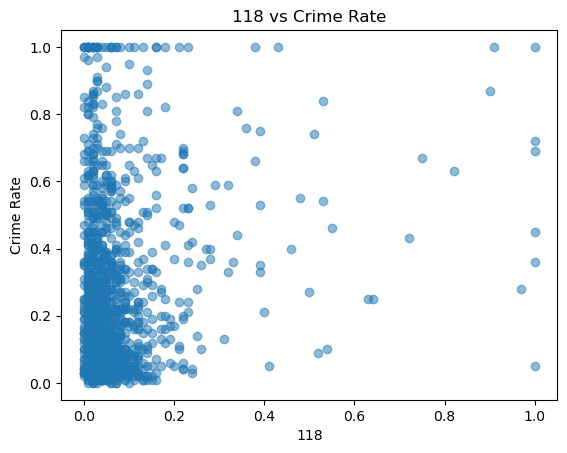

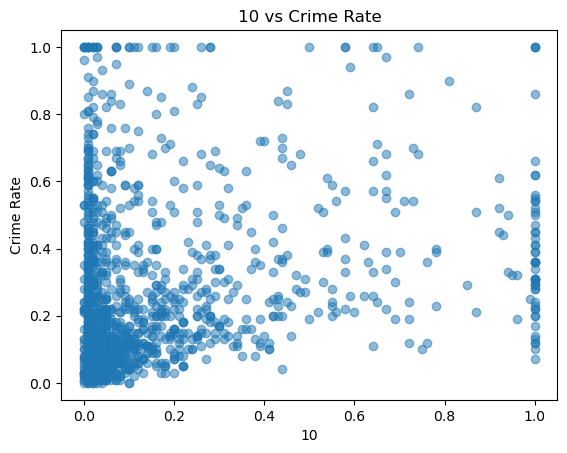

In [142]:
# scatter plots

for col in top_features:
    plt.figure()
    plt.scatter(X_train[col], y_train, alpha=0.5)
    plt.xlabel(col)
    plt.ylabel("Crime Rate")
    plt.title(f"{col} vs Crime Rate")
    plt.show()

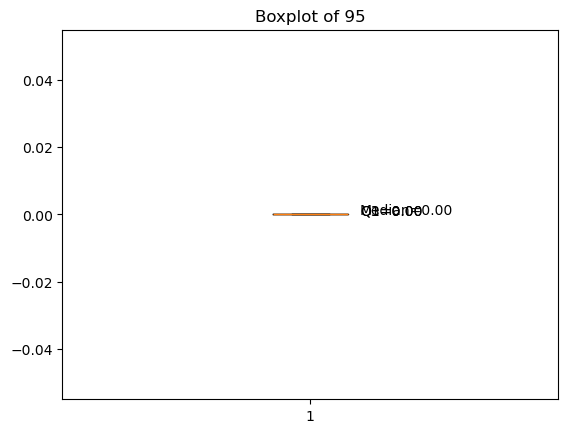

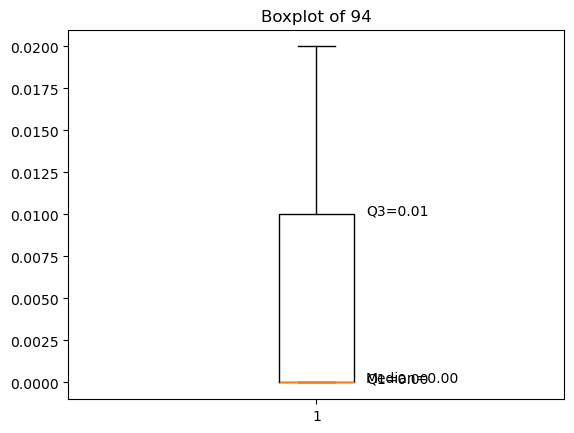

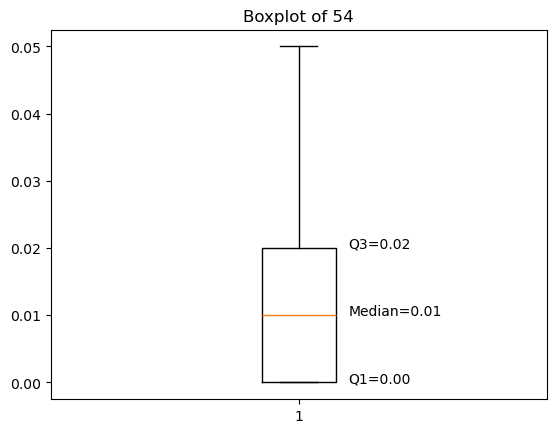

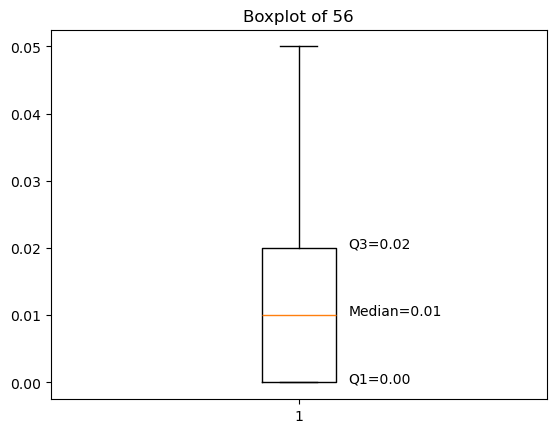

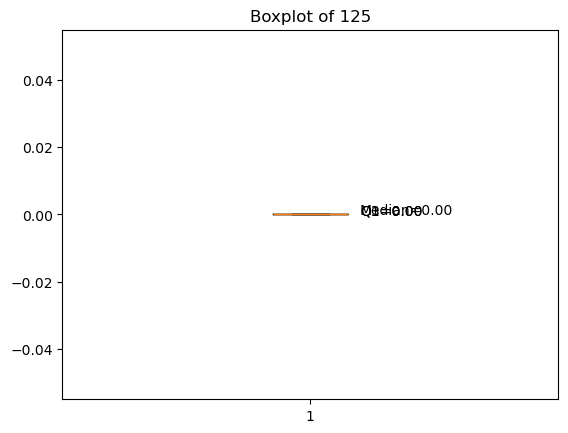

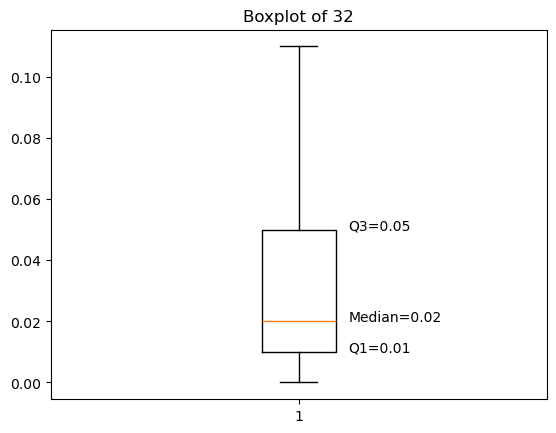

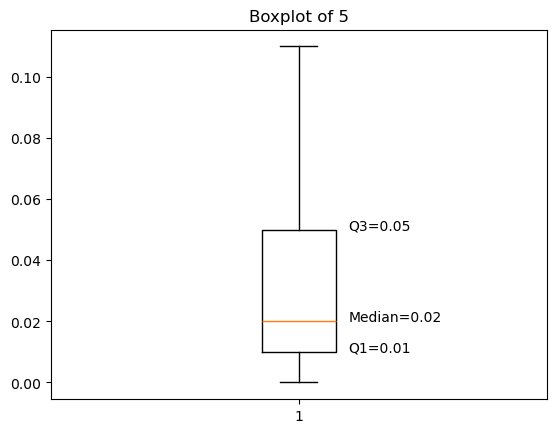

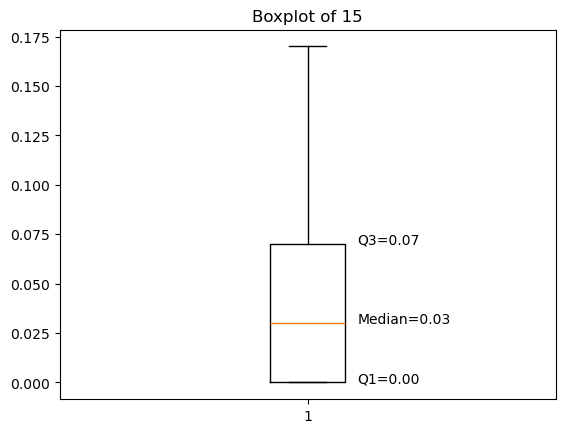

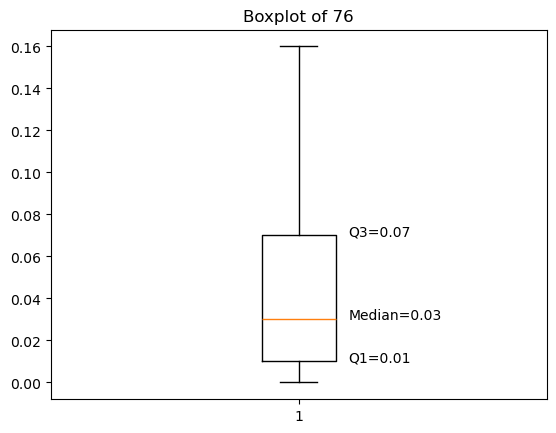

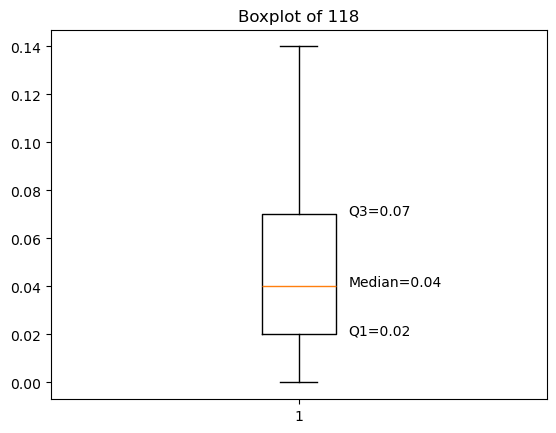

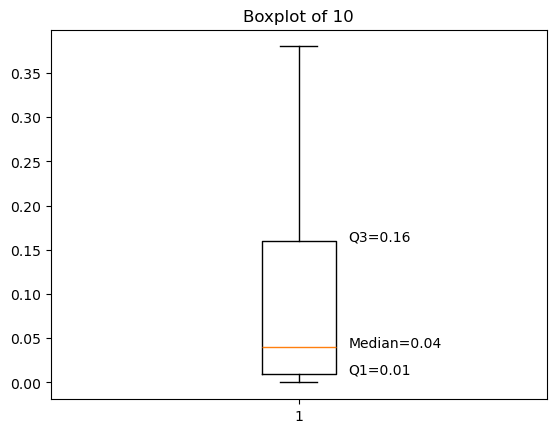

In [143]:
for col in top_features:
    data =X_train[col]
    q1 = np.percentile(data, 25)
    median = np.percentile(data, 50)
    q3 = np.percentile(data, 75)
    plt.figure()
    plt.boxplot(data,showfliers=False) 
    plt.text(1.1, q1, f"Q1={q1:.2f}")
    plt.text(1.1, median, f"Median={median:.2f}")
    plt.text(1.1, q3, f"Q3={q3:.2f}")
    plt.title(f"Boxplot of {col}")
    plt.show()

Scatter plots only provide a visual understanding of the relationship between features and the target variable.
However, they are not sufficient to determine the statistical significance of features. In addition, the relationship only shows the single feature to target variable relationship; however, the impact of multi-features is way important than single feature.

### (f) Fit a linear model

In [144]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# add RMSE due to better interpretation. which reduce the square and align with original unit of data
print("Test MSE:", mse)
print("Test RMSE:", rmse)

Test MSE: 0.7897255274447437
Test RMSE: 0.8886650254425138


### (g) Fit a ridge regression model

In [145]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

In [146]:
alpha = np.logspace(-4, 4, 100) # create value between 10**-4 and 10**4 with 50 values

# Ridge + standardization
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])


# use CV to find the best alpha
#Invalid parameter 'lambda' for estimator Ridge().
#Valid parameters are:
#['alpha', 'copy_X', 'fit_intercept', 'max_iter', 'positive', 'random_state', 'solver', 'tol'].
param_grid = {
    "ridge__alpha": alpha
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train, y_train)

print("Best lambda (alpha):", grid.best_params_["ridge__alpha"])
print("Best CV score:", -grid.best_score_)

Best lambda (alpha): 79.24828983539186
Best CV score: 0.019151634408459524


In [147]:
best_ridge = grid.best_estimator_

y_pred = best_ridge.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)

print("Test MSE:", test_mse)
print("Test RMSE:", test_rmse)

Test MSE: 0.017544199174287792
Test RMSE: 0.1324545173796945


### (h) Fit a LASSO model

In [148]:
from sklearn.linear_model import LassoCV

In [149]:
# Lasso model without standardized features
lasso_raw = LassoCV(
    alphas=np.logspace(-4, 4, 100),
    cv=5,
    max_iter=10000,
    random_state=0
)
lasso_raw.fit(X_train, y_train)

print("Best alpha (raw):", lasso_raw.alpha_)

# test error
y_pred_raw = lasso_raw.predict(X_test)
mse_raw = mean_squared_error(y_test, y_pred_raw)
rmse_raw = np.sqrt(mse_raw)

print("Test MSE (raw):", mse_raw)
print("Test RMSE (raw):", rmse_raw)

# selected variables
selected_raw = X_train.columns[lasso_raw.coef_ != 0]
print("Selected variables (raw):")
print(list(selected_raw))

Best alpha (raw): 0.00012045035402587823
Test MSE (raw): 0.01775229803547754
Test RMSE (raw): 0.13323775003908442
Selected variables (raw):
[7, 9, 11, 12, 16, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 30, 31, 33, 34, 38, 39, 41, 43, 44, 45, 49, 50, 51, 53, 54, 55, 56, 57, 60, 64, 66, 68, 69, 72, 73, 74, 75, 76, 77, 79, 80, 81, 82, 83, 84, 87, 90, 91, 92, 93, 94, 95, 96, 97, 99, 104, 105, 107, 109, 111, 113, 116, 117, 118, 119, 120, 123, 124, 125, 126]


In [150]:
# Lasso model with standardized features
lasso_std = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(
        alphas=np.logspace(-4, 4, 100),
        cv=5,
        max_iter=10000,
        random_state=0
    ))
])

lasso_std.fit(X_train, y_train)

best_alpha_std = lasso_std.named_steps["lasso"].alpha_
print("Best alpha (standardized):", best_alpha_std)

# test error
y_pred_std = lasso_std.predict(X_test)
mse_std = mean_squared_error(y_test, y_pred_std)
rmse_std = np.sqrt(mse_std)

print("Test MSE (standardized):", mse_std)
print("Test RMSE (standardized):", rmse_std)

# selected variables
coef_std = lasso_std.named_steps["lasso"].coef_
selected_std = X_train.columns[coef_std != 0]
print("Selected variables (standardized):")
print(list(selected_std))

Best alpha (standardized): 0.000774263682681127
Test MSE (standardized): 0.017807206177792103
Test RMSE (standardized): 0.13344364420155838
Selected variables (standardized):
[7, 9, 11, 12, 16, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 30, 31, 33, 34, 38, 39, 43, 44, 45, 49, 50, 51, 53, 54, 55, 56, 58, 60, 64, 66, 68, 69, 72, 73, 74, 76, 77, 79, 80, 81, 82, 83, 87, 90, 91, 92, 93, 94, 95, 96, 99, 104, 105, 107, 109, 110, 111, 112, 113, 115, 116, 117, 118, 119, 120, 121, 123, 124]


In [151]:
print("=== Comparison ===")
print("Raw LASSO MSE:", mse_raw)
print("Standardized LASSO MSE:", mse_std)
print("Raw selected variables:", len(selected_raw))
print("Standardized selected variables:", len(selected_std))

=== Comparison ===
Raw LASSO MSE: 0.01775229803547754
Standardized LASSO MSE: 0.017807206177792103
Raw selected variables: 75
Standardized selected variables: 73


Although standardization is generally important for LASSO because it ensures fair penalization across features, in this dataset most variables are already on a similar scale (e.g., between 0 and 1).
Therefore, standardization does not significantly change the model performance or variable selection.

### (i) Fit a PCR model

In [152]:
from sklearn.decomposition import PCA

In [153]:
# PCR = StandardScaler + PCA + LinearRegression
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("lr", LinearRegression())
])

# M = number of principal components
param_grid = {
    "pca__n_components": list(range(1, X_train.shape[1] + 1))
}

# cross-validation to choose M
grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train, y_train)

best_m = grid.best_params_["pca__n_components"]
print("Best M:", best_m)
print("Best CV MSE:", -grid.best_score_)

# test error
best_pcr = grid.best_estimator_
y_pred = best_pcr.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)

print("Test MSE:", test_mse)
print("Test RMSE:", test_rmse)

Best M: 95
Best CV MSE: 0.019354648177616597
Test MSE: 0.018395967491020612
Test RMSE: 0.1356317348227199


The PCR model obtained a higher test MSE than the earlier models.
This is reasonable because PCR selects principal components based on variance in the predictors, not on their relationship with the response variable.
As a result, some components that are useful for prediction may be discarded, leading to worse test performance.

### (j) Fit a boosting tree

In [154]:
!pip install xgboost
from xgboost import XGBRegressor

In [155]:
# Find L1 regularization alpha (= reg_alpha)
param_grid = {
    "reg_alpha": np.logspace(-4, 4, 100)
}


xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=404,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8
)

grid = GridSearchCV(
    xgb,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1 #use all of the CPU
)


grid.fit(X_train, y_train)

best_alpha = grid.best_params_["reg_alpha"]
print("Best alpha:", best_alpha)
print("Best CV MSE:", -grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)

print("Test MSE:", test_mse)
print("Test RMSE:", test_rmse)

Best alpha: 0.7564633275546291
Best CV MSE: 0.019669481149869775
Test MSE: 0.015843192289006786
Test RMSE: 0.12586974334210263
